# Análise de Resultados Históricos (Até 19/04)

Consolidação dos experimentos realizados antes da mudança de formato de dados.

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

sns.set_theme(style="whitegrid")

In [29]:
def load_historical_results(file_path):
    if not os.path.exists(file_path):
        file_path = '../results/experiments.csv' if 'results' not in os.getcwd() else 'experiments.csv'
        
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    data = []
    for line in lines[1:]:
        line = line.strip()
        if not line: continue
        
        parts = line.split(';') if ';' in line else line.split(',')
        
        # Busca dinâmica do timestamp
        timestamp = None
        for p in parts:
            if '2026-04' in p:
                timestamp = p.strip()
                break
        
        if timestamp and timestamp < '2026-04-19':
            
            def parse_metric(val):
                val = str(val).strip()
                if val.count('.') > 1: 
                    return float(val.replace('.', '')) / 1e16
                try:
                    return float(val)
                except ValueError:
                    return None

            try:
                row = {
                    'model': parts[0],
                    'scenario': parts[1],
                    'smote': str(parts[2]).lower() == 'true',
                    'roc_auc': parse_metric(parts[3]), 
                    'f1': parse_metric(parts[4]),
                    'accuracy': parse_metric(parts[5]),
                    'n_features': int(parts[6]),
                    'timestamp': timestamp
                }
                data.append(row)
            except:
                continue
            
    return pd.DataFrame(data)

df = load_historical_results('experiments.csv')

if not df.empty and 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp')
    print(f"Total de experimentos históricos: {len(df)}")
else:
    print("Nenhum dado encontrado para o período anterior a 19/04.")

df.head()

Total de experimentos históricos: 30


,model,scenario,smote,roc_auc,f1,accuracy,n_features,timestamp
0,XGBoost,sem_submodalidade,False,0.930321,0.864498,0.847728,67,2026-04-09 21:01:38.604250
1,XGBoost,sem_submodalidade,True,0.926829,0.867960,0.847673,67,2026-04-09 21:01:48.280996
2,XGBoost,submodalidade_agrupada,False,0.943875,0.088058,0.864592,97,2026-04-09 21:01:52.986582
3,XGBoost,submodalidade_agrupada,True,0.094246,0.884649,0.865943,97,2026-04-09 21:02:03.817310
4,XGBoost,submodalidade_engineered,False,0.930321,0.864498,0.847728,67,2026-04-09 21:02:08.065526


## Melhores Resultados Históricos

In [30]:
if not df.empty:
    metrics = ['roc_auc', 'f1', 'accuracy']
    for metric in metrics:
        if metric in df.columns and not df[metric].dropna().empty:
            best = df.loc[df[metric].idxmax()]
            print(f"Melhor {metric.upper()}: {best[metric]:.4f} | Modelo: {best['model']} | Cenário: {best['scenario']} | SMOTE: {best['smote']}")

Melhor ROC_AUC: 0.9439 | Modelo: XGBoost | Cenário: submodalidade_agrupada | SMOTE: False
Melhor F1: 4.4266 | Modelo: LogisticRegression | Cenário: sem_submodalidade | SMOTE: False
Melhor ACCURACY: 0.8659 | Modelo: XGBoost | Cenário: submodalidade_agrupada | SMOTE: True


## Performance por Modelo

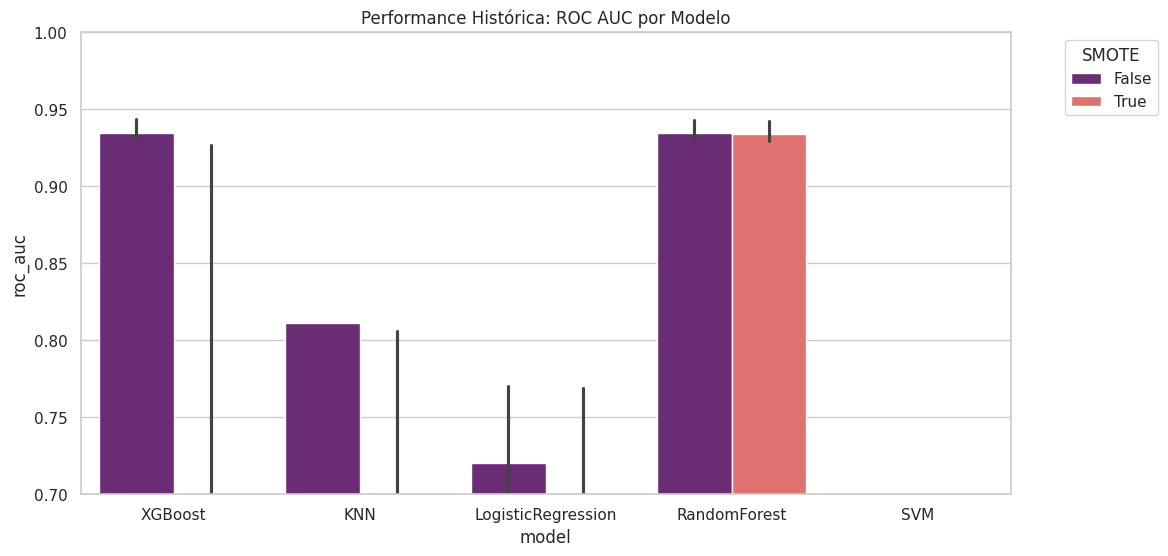

In [31]:
if not df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x='model', y='roc_auc', hue='smote', palette='magma')
    plt.title('Performance Histórica: ROC AUC por Modelo')
    plt.ylim(0.7, 1.0)
    plt.legend(title='SMOTE', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## Tabela de Resultados Históricos (Estilizada)

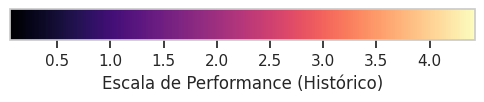

,model,scenario,smote,roc_auc,f1,accuracy,n_features,timestamp
2,XGBoost,submodalidade_agrupada,False,0.943875,0.088058,0.864592,97,2026-04-09 21:01:52.986582
20,RandomForest,submodalidade_agrupada,False,0.943238,0.886033,0.086713,97,2026-04-09 22:13:14.279445
21,RandomForest,submodalidade_agrupada,True,0.942463,0.882779,0.865158,97,2026-04-09 22:13:31.209600
18,RandomForest,sem_submodalidade,False,0.930511,0.087171,0.850830,67,2026-04-09 22:12:49.236498
22,RandomForest,submodalidade_engineered,False,0.930511,0.087171,0.850830,67,2026-04-09 22:13:40.404877
0,XGBoost,sem_submodalidade,False,0.930321,0.864498,0.847728,67,2026-04-09 21:01:38.604250
4,XGBoost,submodalidade_engineered,False,0.930321,0.864498,0.847728,67,2026-04-09 21:02:08.065526
23,RandomForest,submodalidade_engineered,True,0.929446,0.867909,0.849078,67,2026-04-09 22:13:56.123595
19,RandomForest,sem_submodalidade,True,0.929446,0.867909,0.849078,67,2026-04-09 22:13:04.947909
1,XGBoost,sem_submodalidade,True,0.926829,0.867960,0.847673,67,2026-04-09 21:01:48.280996


In [32]:
if not df.empty:
    all_metrics = df[['roc_auc', 'f1', 'accuracy']].values
    norm = mpl.colors.Normalize(vmin=np.nanmin(all_metrics), vmax=np.nanmax(all_metrics))
    sm = plt.cm.ScalarMappable(cmap="magma", norm=norm)

    fig, ax = plt.subplots(figsize=(6, 0.4))
    fig.colorbar(sm, cax=ax, orientation='horizontal', label='Escala de Performance (Histórico)')
    plt.show()

    display(df.sort_values(by='roc_auc', ascending=False).style.background_gradient(subset=['roc_auc', 'f1', 'accuracy'], cmap='magma'))

## Análise - model_results.csv (Histórico)

In [33]:
import pandas as pd
import os

if os.path.exists('model_results.csv'):
    df_models = pd.read_csv('model_results.csv', sep=';')
    df_models['timestamp'] = pd.to_datetime(df_models['timestamp'])
    
    # Filtrando por data
    df_models_filtered = df_models[df_models['timestamp'] < '2026-04-19'].copy()
    
    # Pegando apenas a fase de teste
    df_test = df_models_filtered[df_models_filtered['phase'] == 'test'].copy()
    
    print(f"Total de resultados de teste em model_results.csv (Histórico): {len(df_test)}")
    
    if not df_test.empty:
        # Removendo colunas desnecessárias ou formatando
        display(df_test.sort_values(by='roc_auc', ascending=False).style.background_gradient(subset=['roc_auc', 'f1', 'accuracy'], cmap='magma'))
else:
    print("Arquivo model_results.csv não encontrado.")


Total de resultados de teste em model_results.csv (Histórico): 5


,model,scenario,smote,phase,roc_auc,f1,accuracy,best_params,timestamp
9,RandomForest,sem_submodalidade,False,test,0.932190,0.874057,0.853732,"{'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}",2026-04-09 23:10:35.375419
1,XGBoost,sem_submodalidade,False,test,0.930373,0.864766,0.848184,"{'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}",2026-04-09 21:04:33.153976
5,DecisionTree,sem_submodalidade,False,test,0.910683,0.854567,0.830973,"{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}",2026-04-09 21:57:58.046473
3,KNN,sem_submodalidade,False,test,0.828980,0.782287,0.746322,"{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}",2026-04-09 21:46:50.358381
7,LogisticRegression,sem_submodalidade,False,test,0.695678,0.442656,0.562730,"{'C': 1, 'solver': 'lbfgs'}",2026-04-09 22:07:49.514070
